In [21]:
# --------------------------------
# Imports & Path Setup
# --------------------------------

%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision.utils import save_image
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim

from src.utils.trainer import Trainer
from src.utils.logger import Logger

In [22]:
# --------------------------------
# Trainer Setup
# --------------------------------

LOG_DIR = Path("../logs")

logger = Logger(
    dir=LOG_DIR,
    description="ConvAutoencoder-SkipConnections"
)

# ConvAutoencoder
trainer = Trainer(
    input_dir=Path("../data/resized"),
    compressed_dir=Path("../data/compressed"),
    checkpoints_dir=Path("../checkpoints"),
    checkpoint_name="best_model_autoencoder",
    logger=logger,
    base_channels=32,
    batch_size=4,
    learning_rate=1e-3,
    weight_decay=1e-4,
)

trainer.load_dataset()

Device : cpu
Parameters : 2,389,859
Train	| Val	| Test : 
70	| 15	| 15


In [23]:
# --------------------------------
# Training
# --------------------------------

history = trainer.train(num_epochs=100)

Epoch   1/100  |  Train Loss: 0.321220  |  Val Loss:   0.318709
Epoch  10/100  |  Train Loss: 0.181620  |  Val Loss:   0.192630
Epoch  20/100  |  Train Loss: 0.169446  |  Val Loss:   0.182189
Epoch  30/100  |  Train Loss: 0.155137  |  Val Loss:   0.179301
Epoch  40/100  |  Train Loss: 0.133856  |  Val Loss:   0.180507
Epoch  50/100  |  Train Loss: 0.096276  |  Val Loss:   0.180839
Epoch  60/100  |  Train Loss: 0.069632  |  Val Loss:   0.186138
Epoch  70/100  |  Train Loss: 0.053271  |  Val Loss:   0.186053
Epoch  80/100  |  Train Loss: 0.043827  |  Val Loss:   0.188930
Epoch  90/100  |  Train Loss: 0.040689  |  Val Loss:   0.190388
Epoch 100/100  |  Train Loss: 0.038639  |  Val Loss:   0.191566

Training complete — Best val loss: 0.177747 (epoch 36)
Checkpoint saved: ../checkpoints/best_model_autoencoder_20260309_130926.pth
[Logger] Log saved to: ../logs/20260309_130926_ConvAutoencoder-SkipConnections.log


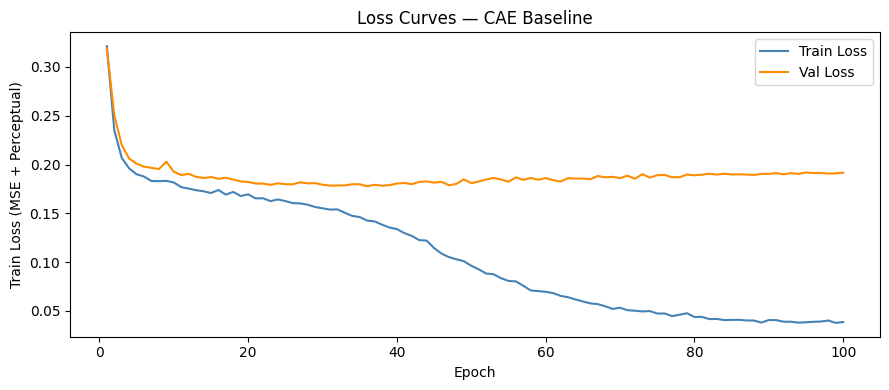

In [24]:
# --------------------------------
# Loss Curves
# --------------------------------

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
plt.plot(epochs, history["val_loss"], label="Val Loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Train Loss (MSE + Perceptual)")
plt.title("Loss Curves — CAE Baseline")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# --------------------------------
# Load Best Checkpoint
# --------------------------------

trainer.model.load_state_dict(
    torch.load(
        Path("../checkpoints/best_model_autoencoder.pth"), map_location=trainer.device
    )
)
trainer.model.eval()
print(" Best model loaded")

 Best model loaded


In [26]:
# --------------------------------
# Baseline PSNR — Compressed vs Original
# --------------------------------

psnr_baseline, ssim_baseline = [], []

for compressed, original in trainer.test_loader:
    for comp_t, orig_t in zip(compressed.numpy(), original.numpy()):
        comp_np = np.transpose(comp_t, (1, 2, 0))
        orig_np = np.transpose(orig_t, (1, 2, 0))
        psnr_baseline.append(calc_psnr(orig_np, comp_np, data_range=1.0))
        ssim_baseline.append(
            calc_ssim(orig_np, comp_np, data_range=1.0, channel_axis=2)
        )

psnr_base = np.mean(psnr_baseline)
ssim_base = np.mean(ssim_baseline)
print(f"Baseline  —  PSNR: {psnr_base:.2f} dB  |  SSIM: {ssim_base:.4f}")

Baseline  —  PSNR: 26.38 dB  |  SSIM: 0.7722


In [27]:
# --------------------------------
# PSNR / SSIM — Restored vs Original
# --------------------------------

psnr_list, ssim_list = [], []

with torch.no_grad():
    for compressed, original in trainer.test_loader:
        compressed = compressed.to(trainer.device)
        original = original.to(trainer.device)
        recon, _ = trainer.model(compressed)

        for out_t, orig_t in zip(recon.cpu().numpy(), original.cpu().numpy()):
            out_np = np.transpose(out_t, (1, 2, 0))
            orig_np = np.transpose(orig_t, (1, 2, 0))
            psnr_list.append(calc_psnr(orig_np, out_np, data_range=1.0))
            ssim_list.append(calc_ssim(orig_np, out_np, data_range=1.0, channel_axis=2))

psnr_mean = np.mean(psnr_list)
ssim_mean = np.mean(ssim_list)

print(f"{'─' * 50}")
print(f"  PSNR baseline (compressed) : {psnr_base:.2f} dB")
print(
    f"  PSNR restored              : {psnr_mean:.2f} dB  ({psnr_mean - psnr_base:+.2f})"
)
print(f"  SSIM baseline (compressed) : {ssim_base:.4f}")
print(f"  SSIM restored              : {ssim_mean:.4f}  ({ssim_mean - ssim_base:+.4f})")
print(f"{'─' * 50}")

──────────────────────────────────────────────────
  PSNR baseline (compressed) : 26.38 dB
  PSNR restored              : 24.46 dB  (-1.92)
  SSIM baseline (compressed) : 0.7722
  SSIM restored              : 0.7064  (-0.0658)
──────────────────────────────────────────────────
